# 第059讲 树的复杂度与剪枝

先在纸上完成四叶树例子，再运行本Notebook。代码按训练→验证选择→最终测试顺序执行，所有数据随包提供。图表与正文对应。

In [1]:
from pathlib import Path
import json
import numpy as np
from experiment import run
from common import write_json
result = run()
write_json('outputs/notebook-result.json', result)
print(result['choices'])

{'pre_index': 3, 'post_index': 34, 'pre': {'max_depth': 2, 'min_samples_leaf': 1, 'depth': 2, 'n_leaves': np.int64(4), 'validation_brier': 0.1568201613201229}, 'post_alpha': 0.01059069603906565, 'selection': 'validation Brier; exact ties fewer leaves, lower depth, earlier row', 'refit': False}


## 路径并不等于调参结果
路径只用训练数据得到；validation_brier提供选择证据。观察复杂度减少时训练风险的代价。

In [2]:
[(r['alpha'],r['n_leaves'],r['risk'],r['validation_brier']) for r in result['path'][-8:]]

[(0.005370536428659853, 10, 0.2546416844272498, 0.20808576673346402),
 (0.0061363636363636394, 8, 0.26691441169997715, 0.20351159317974502),
 (0.007118944473470334, 6, 0.2811523006469178, 0.19082976932857054),
 (0.007750915750915749, 5, 0.2889032163978335, 0.17944990913991912),
 (0.008472268472268465, 4, 0.297375484870102, 0.17000620155435342),
 (0.01059069603906565, 3, 0.3079661809091676, 0.15430787336141716),
 (0.05876130904412877, 2, 0.36672748995329635, 0.19631128552895652),
 (0.09530707794793825, 1, 0.4620345679012346, 0.2206074074074074)]

## 冻结后查看测试
这里同时报告预先确定的三个策略。不要在这些测试数值上重新选择α。

In [3]:
for name,row in result['evaluation'].items():
    print(name, {k:v for k,v in row.items() if k!='probability'})

unrestricted {'accuracy': 0.68, 'brier': 0.32, 'depth': 11, 'n_leaves': np.int64(95)}
pre {'accuracy': 0.7466666666666667, 'brier': 0.163508175812183, 'depth': 2, 'n_leaves': np.int64(4)}
post {'accuracy': 0.7466666666666667, 'brier': 0.16417774049143466, 'depth': 2, 'n_leaves': 3}
constant {'accuracy': 0.6088888888888889, 'brier': 0.23897777777777776}


## 独立审计
检查从标签重算风险、重算全部候选与验证选择；使用显式异常，优化模式不会移除。

In [4]:
from test_experiment import audit
checks=audit(result)
print(checks['status'], checks['checks'])

passed 2751


## 重新绘制六幅图
图3先展示预剪枝选择；图1解释手算目标；图2追踪路径；图4至6检查区域与稳定性。

01_cost_lines.png


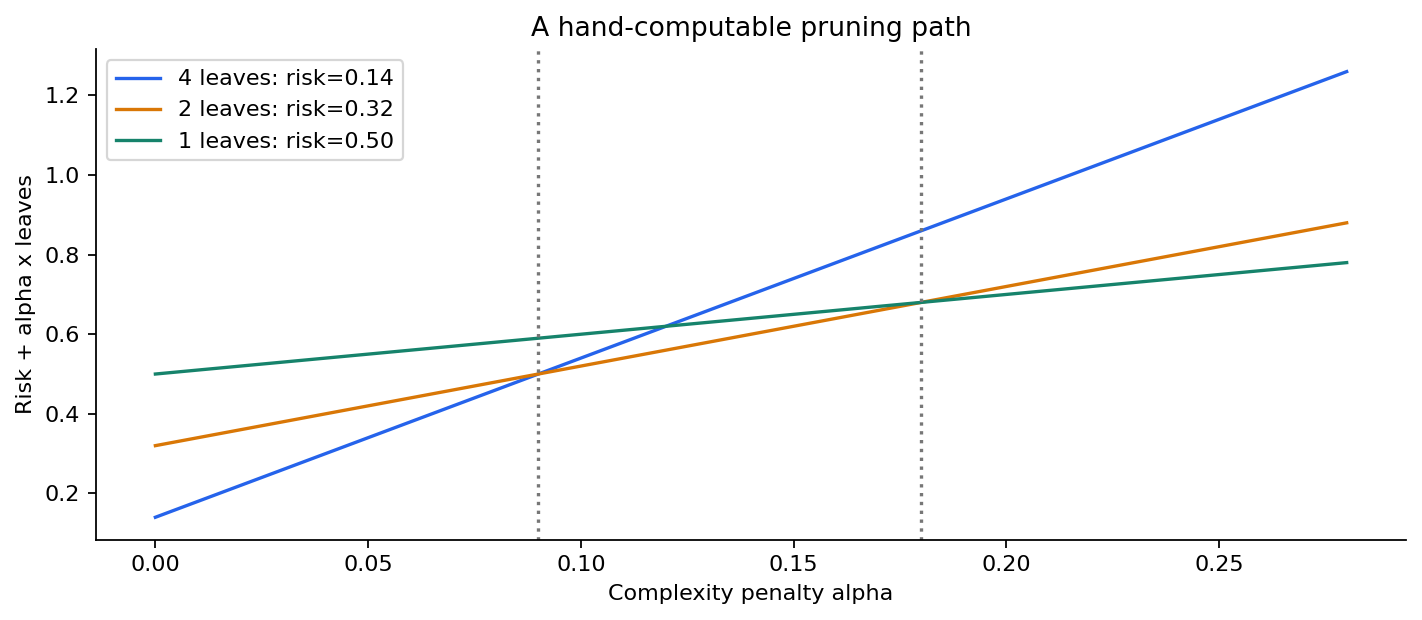

02_pruning_path.png


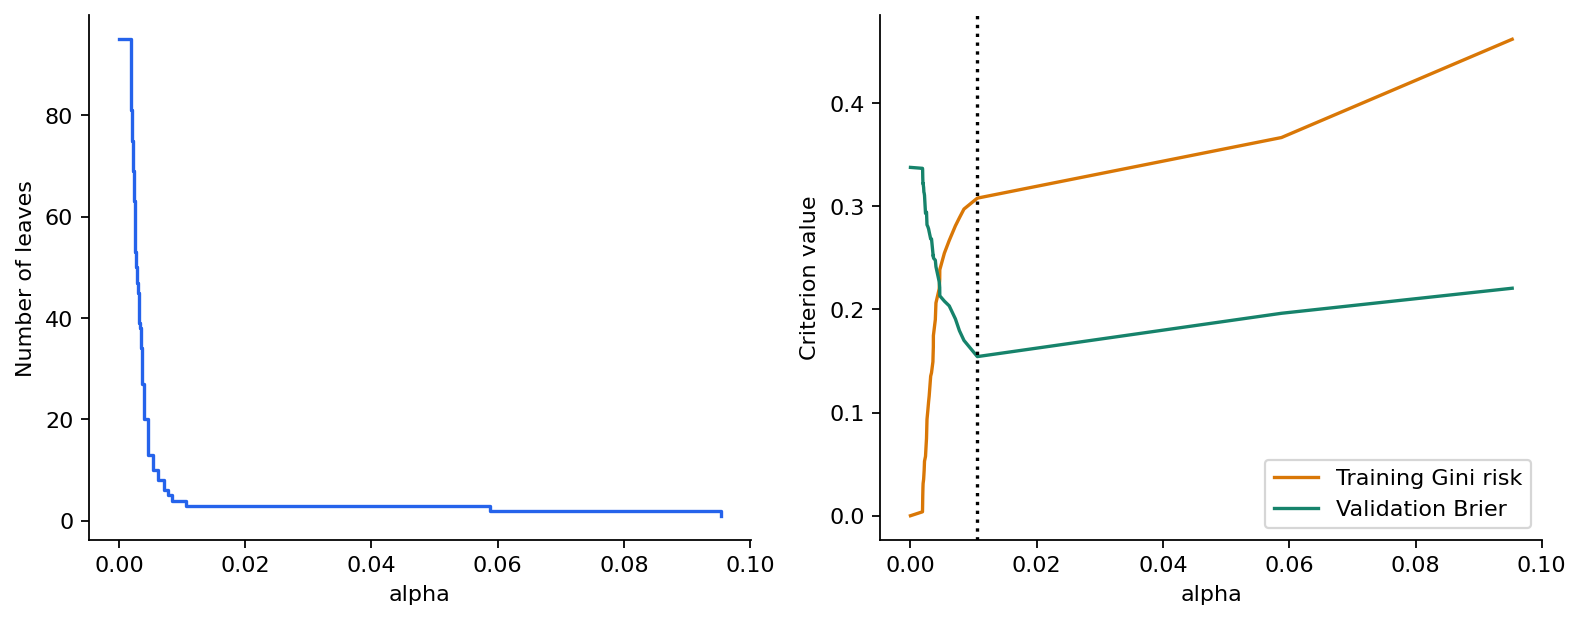

03_pre_grid.png


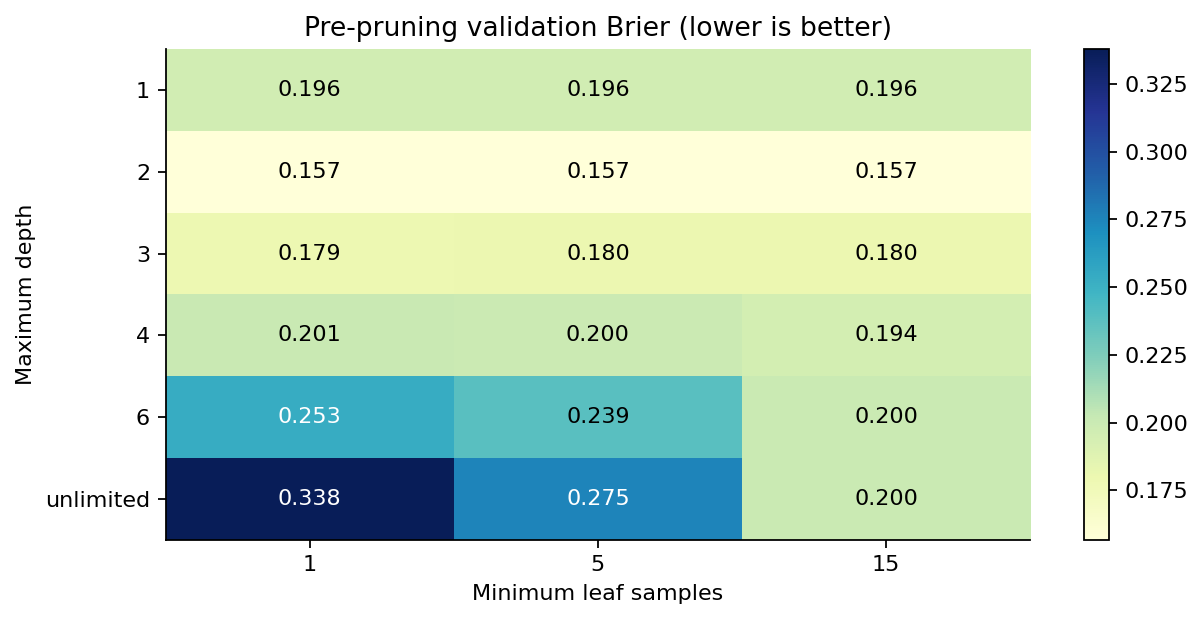

04_regions.png


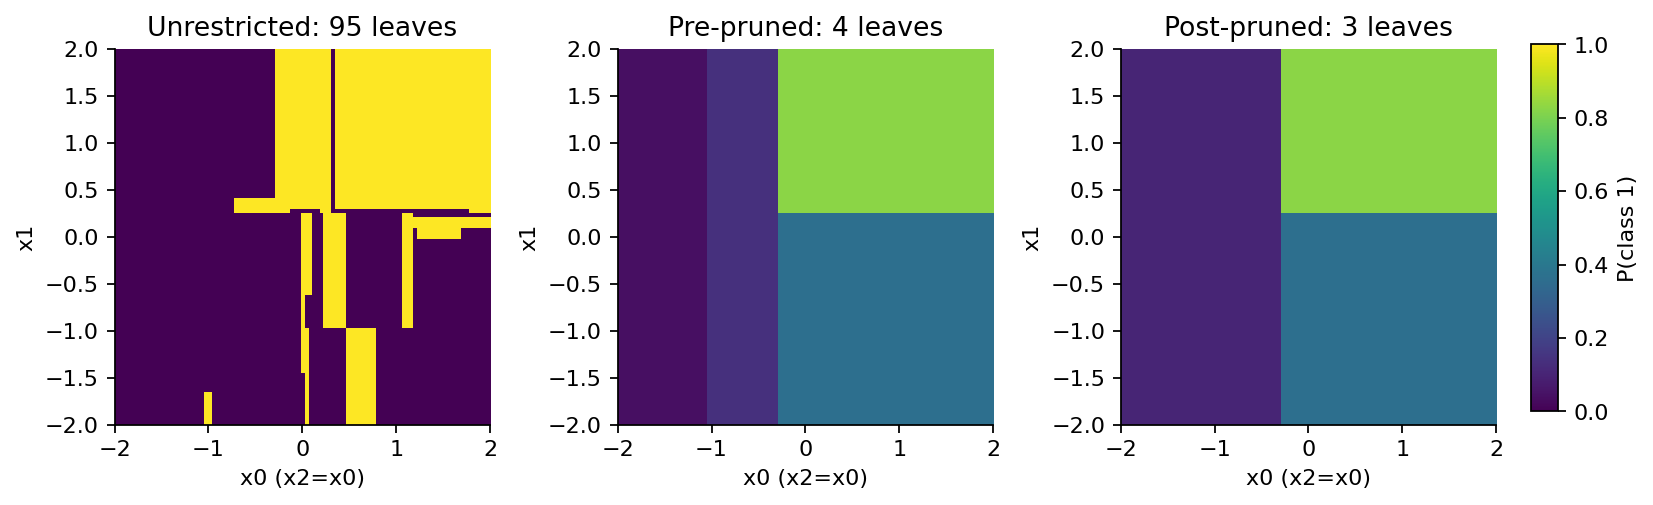

05_stability.png


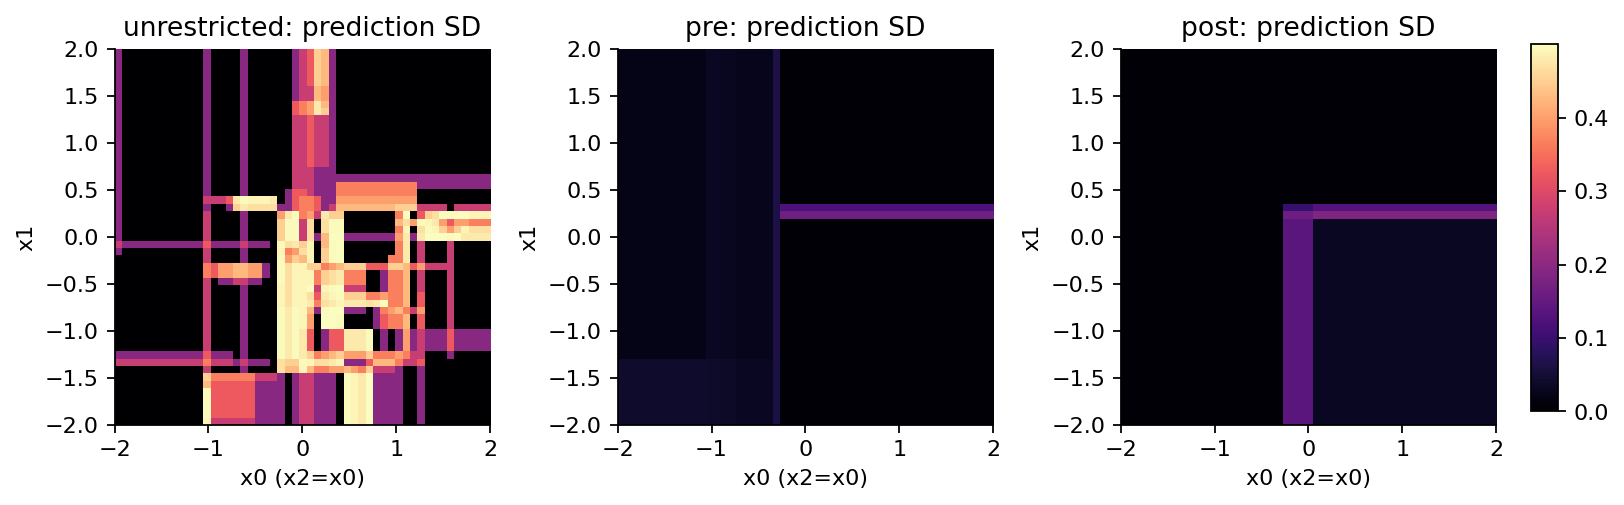

06_selected_tree.png


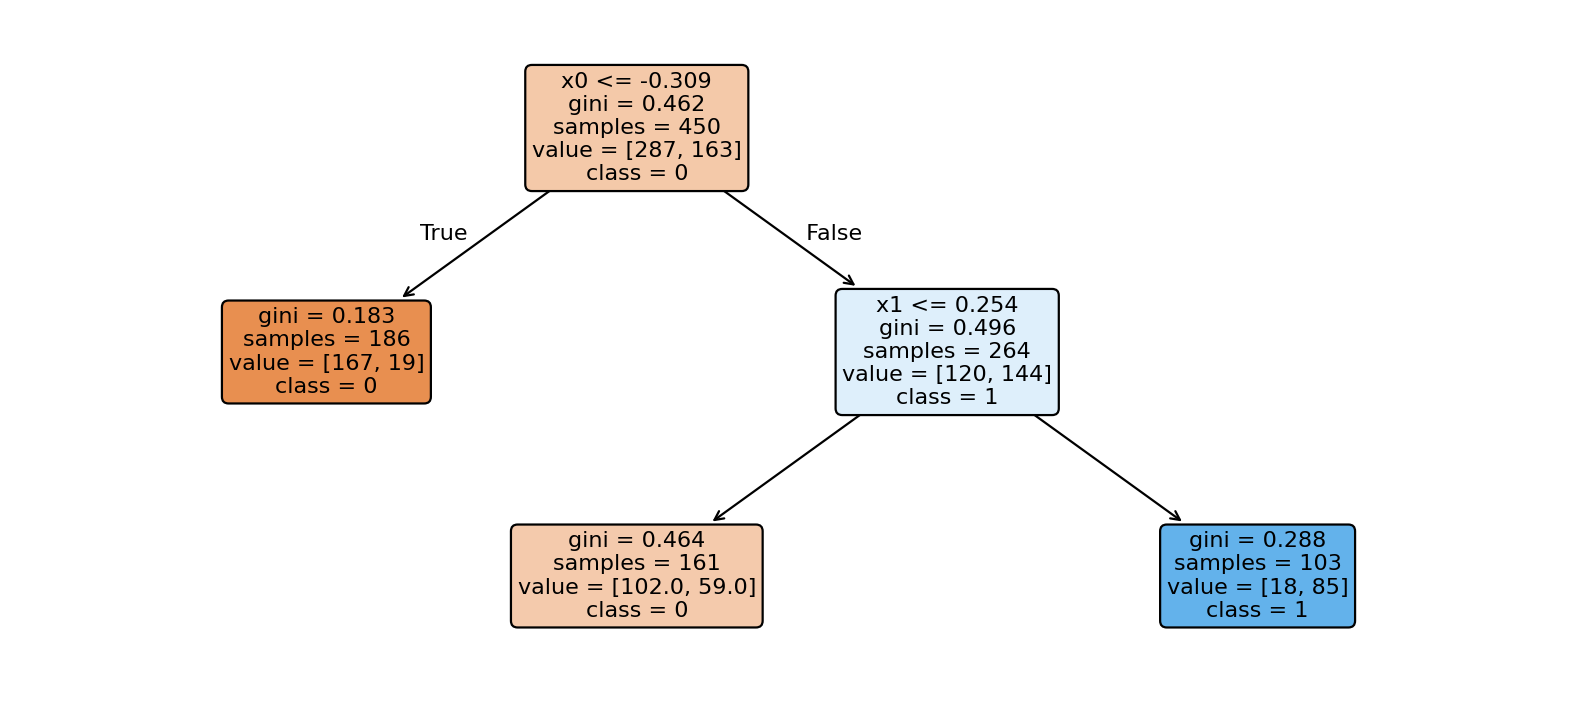

In [5]:
from plots import build
from IPython.display import display, Image
build(result, 'outputs/notebook-figures')
for file in sorted(Path('outputs/notebook-figures').glob('*.png')):
    print(file.name)
    display(Image(filename=str(file)))

## 比较扰动敏感性
25次删行共享大部分原始样本；这些标准差不是总体置信区间。

In [6]:
for name,row in result['stability'].items():
    print(name, 'probability variance=',row['probability_variance_mean'], 'pair disagreement=',row['pair_disagreement'])

unrestricted probability variance= 0.0470883506343714 pair disagreement= 0.09810073048827374
pre probability variance= 0.0009166609288297882 pair disagreement= 0.004831475073689606
post probability variance= 0.00166775501663937 pair disagreement= 0.027376650006407786


## 小实验
复制报告后改坏一个风险，检查审计是否拒绝；不要修改发布文件。随后回答lab.md的12题，并用answers.md核对过程。

In [7]:
import copy
bad=copy.deepcopy(result)
bad['evaluation']['post']['brier']=0.0
try:
    audit(bad)
except RuntimeError as error:
    print('Expected rejection:', error)
else:
    raise RuntimeError('Tampered report was not rejected')

Expected rejection: FAILED: post held-out Brier
